## Módulo III: Preprocesamiento 

### Datos nulos  y su tratamiento II

#### Objetivo

* Entender y utilizar el RMSE como métrica de ajuste en un modelo de regresión.
* Presentar un problema de serie de tiempo en el cual se necesiten sustituir datos (durante y después).
    * Hablar de variables muy básicas para entrenar: Rezagos de la serie (estilo modelos AR).
    * Por no ser el objetivo de la actividad, no se separarán conjuntos train/test/OOS/OOT.
* Crear un método de sustitución de datos vía regresión.
* Mostrar gráficamente el ajuste de los datos.
    * Adjuntar RMSE.

#### Actividad 1 guiada:
* Tomar los datos de `actividad1_6_0.csv`.
* Graficar los datos.
* Crear un método de regresión en el cual se muestren gráficamente además de con una medición de RMSE.
    * Probar el performance comparando con el archivo `actividad1a_6_0.csv`.
 
#### Actividad 2 autónoma:
* Repetir actividad uno con el archivo `actividad2_6_0.csv`.
* Probar el performance del modelo con los datos reales en el archivo `actividad2a_6_0.csv`.
    * En este archivo viene toda la serie de tiempo.
* Responda: 
    * ¿Por qué el modelo de la actividad 1 tuvo un mejor ajuste? 



In [1]:
import os
import datetime
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd
from copy import deepcopy
import numpy as np
%matplotlib inline
plt.style.use('ggplot')

Un modelo de regresión se puede definir de la siguiente forma:
$$\hat{y} = \beta_0x_0 + \beta_1x_1 + \cdots + \beta_nx_n$$
donde $x$ representa a nuestra(s) variable(s) y las betas ($\beta$) representan los coeficientes elegidos. 

Un mayor coeficiente naturalmente representará una mayor influencia por parte de esa variable.


##### ¿Cómo usar un modelo de regresión para llenado de datos? 

Imaginemos que tenemos una serie de tiempo, es decir, datos ordenados a través de la historia (sea ésta minutos, días, meses o cualquier otro). Puede ser que por razones exógenas e incluso desconocidas, se dejaron de registrar datos, por lo que un modelo de este tipo nos puede ayudar para _interpolar_ (datos entre la misma serie) o _extrapolar_ (datos más allá de la serie) información.

Otro ejemplo puede ser en un caso que no sea serie de tiempo, es decir, que tenemos ciertas variables numéricas que simplemente carecen de información (los famosos _nulos_). En ese caso, podemos usar información de otras variables de nuestro dataset para, de nuevo con una regresión, tratar de _rellenar_ la información faltante.


Un modelo usado para _rellenar_ nulos se vería de la siguiente forma: 
$$\hat{y_{t}} = \beta_0y_{t-1} + \beta_1y_{t-2} + \cdots + \beta_ny_{t-n}$$

### Actividad 1: Usando regresiones en acciones de la bolsa

In [2]:
basedir = '.'
df = pd.read_csv(os.path.join(basedir, 'actividad1_6_0.csv'), index_col=0) 
cheat_df = pd.read_csv(os.path.join(basedir, 'actividad1a_6_0.csv'), index_col=0) 

In [3]:
df.head(10)

,Close
Date,
2020-01-02,858.190002
2020-01-03,865.130005
2020-01-06,858.020020
2020-01-07,860.080017
2020-01-08,856.729980
2020-01-09,862.669983
2020-01-10,857.770020
2020-01-13,863.000000
2020-01-14,859.219971


Tenemos una serie de tiempo de `CMG` (Chipotle Mexican Grill). Es la cotización del precio de la acción de la mencionada empresa. 

Analicemos cómo se ve nuestra serie.

Text(0, 0.5, 'USD price')

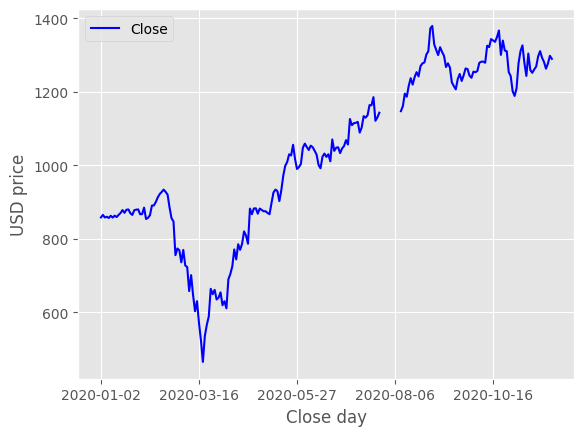

In [4]:
df.plot(kind="line", color="blue")
plt.xlabel('Close day')
plt.ylabel('USD price')

Vemos que a nuestra serie de tiempo le faltan pedazos. Como no tenemos otra información más allá del paso del tiempo, lo usaremos a nuestro favor creando **rezagos**, es decir: $t-1, t-2, \dots, t-n$.

In [5]:
lags = list(range(1, 8, 1))

Creamos un DataFrame con columnas para los razones

In [14]:
#lagged_frame = pd.DataFrame(data=None, columns = ['t'] + [f't -{d}' for d in lags])
lagged_frame = pd.DataFrame(data=None, columns=['t'] + [f't-{d}' for d in lags])
lagged_frame['t'] = df.Close.values

In [15]:
lagged_frame.head()

,t,t-1,t-2,t-3,t-4,t-5,t-6,t-7
0,858.190002,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,865.130005,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,858.020020,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,860.080017,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,856.729980,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Usaremos el método shift de pandas para causar rezagos.

In [17]:
for lag in lags:
    lagged_frame[f't-{lag}'] = lagged_frame['t'].shift(lag)

In [18]:
lagged_frame.head(8)

,t,t-1,t-2,t-3,t-4,t-5,t-6,t-7
0,858.190002,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,865.130005,858.190002,NaN,NaN,NaN,NaN,NaN,NaN
2,858.020020,865.130005,858.190002,NaN,NaN,NaN,NaN,NaN
3,860.080017,858.020020,865.130005,858.190002,NaN,NaN,NaN,NaN
4,856.729980,860.080017,858.020020,865.130005,858.190002,NaN,NaN,NaN
5,862.669983,856.729980,860.080017,858.020020,865.130005,858.190002,NaN,NaN
6,857.770020,862.669983,856.729980,860.080017,858.020020,865.130005,858.190002,NaN
7,863.000000,857.770020,862.669983,856.729980,860.080017,858.020020,865.130005,858.190002


¿Cómo se ve nuestra serie rezagada?

Text(0.5, 1.0, 'Lagged Chipotle')

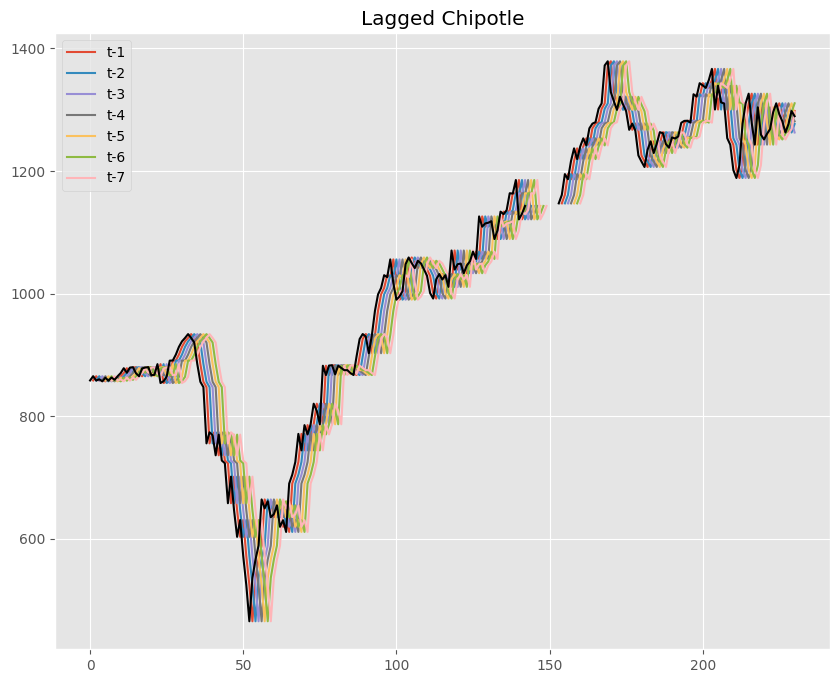

In [19]:
lag_names = [f't-{lag}' for lag in lags]
lagged_frame[lag_names].plot(figsize=(10, 8))

lagged_frame['t'].plot(figsize=(10, 8), color='black')

plt.title('Lagged Chipotle')

In [20]:
lagged_copy = lagged_frame.copy()
lagged_copy2 = lagged_frame.copy()

lagged_copy.dropna(inplace=True)

Ahora nuestro DataFrame tiene "nuevas variables" que usaremos como predictores. Es decir, cada punto en $t$ se volverá una función de los puntos en $t-n, n>0$.


Dado a que el objetivo del modelo es **rellenar información**, podemos usar ambas partes de la gráfica. 

In [21]:
modelo = LinearRegression()

response = ['t']
predictores = sorted(set(lagged_copy.columns).difference(response))

In [22]:
modelo.fit(lagged_copy[predictores], lagged_copy[response])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Fitteamos el modelo

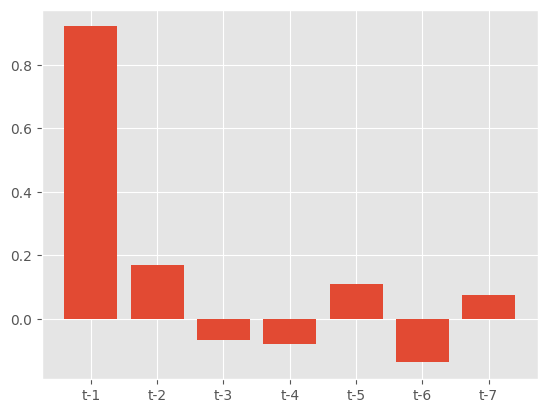

In [23]:
fig, ax = plt.subplots()
index = range(len(predictores))

ax.bar(index, modelo.coef_[0])
ax.set_xticks(index)
ax.set_xticklabels(predictores)
plt.show()

Veamos nuestros coeficientes y respondamos: ¿En qué se fija nuestro modelo?

Usemos nuestro modelo para estimar las partes que faltan. 
Tomaremos la serie donde tenía huecos y acomodemos el DataFrame.

In [24]:
df_to_estimate = lagged_frame.loc[lagged_frame['t'].isnull()]

In [25]:
index_to_estimate = df_to_estimate.index.tolist()

Podemos ver que nos falta información, vamos a tener que irla rellenando y _acumulando el error_ (punto negativo a este método).

In [26]:
estimaciones = []

primera_posicion = min(index_to_estimate)

values_reshape = df_to_estimate.loc[primera_posicion, predictores].values.reshape(1, -1)
values_reshape.shape

(1, 7)

In [27]:
estimaciones.append(modelo.predict(values_reshape)[0][0])

C:\Users\TAJ\Desktop\Data Lab\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Vamos a comenzar a estimar el primer punto: 

In [28]:
estimaciones

[np.float64(1138.776237489812)]

Antes de ponerlo en nuestro DataFrame e iterar el proceso, recordemos cómo es que se ve: 

In [29]:
lagged_copy2.loc[primera_posicion, 't'] = estimaciones[0]
lagged_copy2.loc[index_to_estimate]

,t,t-1,t-2,t-3,t-4,t-5,t-6,t-7
143,1138.776237,1142.930054,1130.260010,1121.030029,1185.270020,1163.099976,1163.719971,1136.219971
144,NaN,NaN,1142.930054,1130.260010,1121.030029,1185.270020,1163.099976,1163.719971
145,NaN,NaN,NaN,1142.930054,1130.260010,1121.030029,1185.270020,1163.099976
146,NaN,NaN,NaN,NaN,1142.930054,1130.260010,1121.030029,1185.270020
147,NaN,NaN,NaN,NaN,NaN,1142.930054,1130.260010,1121.030029
148,NaN,NaN,NaN,NaN,NaN,NaN,1142.930054,1130.260010
149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1142.930054
150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
151,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Ahora sí lo colocamos otra vez en nuestro DataFrame.

In [32]:
# Colocando las respuestas en un copy 
for lag in lags:
    lagged_copy2[f't-{lag}'] = lagged_copy2['t'].shift(lag)
 

In [34]:
#lagged_copy2.loc[index_to_estimate]

Hecho eso, tenemos que volver a alimentar nuestro frame, es decir, incorporar el dato estimado en `t` (índice 143) como nuestro `t-1` en el índice 144 (el día siguiente).

In [35]:
for posicion, index in enumerate(index_to_estimate[1::]):
    values_reshape = lagged_copy2.loc[index, predictores].values.reshape(1, -1)

    estimaciones.append(modelo.predict(values_reshape)[0][0])

    lagged_copy2.loc[index, 't'] = estimaciones[posicion + 1]

    for lag in lags:
        lagged_copy2[f't-{lag}'] = lagged_copy2['t'].shift(lag)

C:\Users\TAJ\Desktop\Data Lab\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\TAJ\Desktop\Data Lab\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\TAJ\Desktop\Data Lab\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\TAJ\Desktop\Data Lab\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\TAJ\Desktop\Data Lab\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with featur

Hecho eso, iteremos siguiente el siguiente procedimiento: 

* Estimemos el dato en `t` con la serie desde `t-1` hasta `t-7` llena. 
* Tomemos ese dato estimado y llevémoslo como el `t-1` del día siguiente. 
* Repetir procedimiento pero llenando todos los días previos con estimaciones según vayamos avanzando. 
    

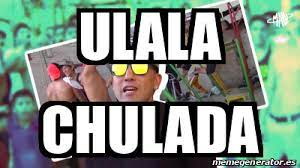

Veamos qué tal se ve la serie: 

¿Cómo definir si un modelo estuvo bien, mal o en el hoyo y cavando? 

Tomemos nuestros datos reales y comparemos con las estimaciones. Para medición del error usaremos el RMSE. 

$$\text{RMSE} = \frac{1}{n} \sum_{i=0}^n (y_i - \hat{y_i})^2$$

Vayamos por partes y primero obtengamos las diferencias. 

Obtengamos el cuadrado. Esta es una buena forma de:
* "Exagerar" las diferencias. Es un "hack" para identificar si las diferencias son chicas o grandes. 
* Eliminar el efecto de "eliminación por signo" (neteo). 

Obtengamos el promedio. 

Regresemos a unidades interpretables (dólares en este caso).

En el futuro podremos utilizar la función de `scikit`: 